In [52]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
import json
import pathlib

import sig_analize as san
import generate_areas as ga
import sequence_image_anal_function as siaf
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
dir_path = './data/drop-211025-2'
img_path_list = [dir_path + '/' + f for f in os.listdir(dir_path) if f.endswith('.jpg')]
img_path_list.sort()
img_path_list

['./data/drop-211025-2/drop-0050.jpg',
 './data/drop-211025-2/drop-0060.jpg',
 './data/drop-211025-2/drop-0070.jpg',
 './data/drop-211025-2/drop-0080.jpg',
 './data/drop-211025-2/drop-0090.jpg',
 './data/drop-211025-2/drop-0100.jpg',
 './data/drop-211025-2/drop-0110.jpg',
 './data/drop-211025-2/drop-0120.jpg',
 './data/drop-211025-2/drop-0130.jpg',
 './data/drop-211025-2/drop-0140.jpg',
 './data/drop-211025-2/drop-0150.jpg',
 './data/drop-211025-2/drop-0160.jpg',
 './data/drop-211025-2/drop-0170.jpg',
 './data/drop-211025-2/drop-0180.jpg']

In [65]:
img_path = img_path_list[0]

roi_area = ga.get_area_box(img_path)
roi_area

(179, 313, 63, 21)

In [66]:
# we want to create samples of roi from chosen area on the img

# hights and width of chosen area
L = roi_area[2]
H = roi_area[3]
print(f"L = {L}; H = {H}")

# define limits of height and width for rois
Lmin = 3*L//4
Hmin = 3
Hmax = 10
if H < Hmax:
    Hmax = H
print(f"Lmin = {Lmin}; Lmax = {L}; Hmin = {Hmin}; Hmax = {H}")

# create possible pairs of coordinates within area, which comply with height and width  restrictions
# j1,j2 - begining and end points on "length" axis
# i1,i2 - begining and end points on "height" axis
j_list = [(j1, j2) for j1 in range(L - Lmin + 1) for j2 in range(Lmin + j1 - 1, L)]
i_list = [(i1, i2) for i1 in range(H - Hmin + 1) for i2 in range(Hmin + i1 - 1, min(H, i1 + Hmax - 1))]

print(j_list)
print(i_list)

# choose randomly from  created lists
rng = np.random.default_rng()

size = 10
chosen_j = rng.choice(j_list, size=size)
chosen_i = rng.choice(i_list, size=size)

# calculate length and height for chosen rois 
l_list = [j[1]-j[0]+1 for j in chosen_j]
h_list = [i[1]-i[0]+1 for i in chosen_i]

print(chosen_j)
print(chosen_i)
print(l_list)
print(h_list)

L = 63; H = 21
Lmin = 47; Lmax = 63; Hmin = 3; Hmax = 21
[(0, 46), (0, 47), (0, 48), (0, 49), (0, 50), (0, 51), (0, 52), (0, 53), (0, 54), (0, 55), (0, 56), (0, 57), (0, 58), (0, 59), (0, 60), (0, 61), (0, 62), (1, 47), (1, 48), (1, 49), (1, 50), (1, 51), (1, 52), (1, 53), (1, 54), (1, 55), (1, 56), (1, 57), (1, 58), (1, 59), (1, 60), (1, 61), (1, 62), (2, 48), (2, 49), (2, 50), (2, 51), (2, 52), (2, 53), (2, 54), (2, 55), (2, 56), (2, 57), (2, 58), (2, 59), (2, 60), (2, 61), (2, 62), (3, 49), (3, 50), (3, 51), (3, 52), (3, 53), (3, 54), (3, 55), (3, 56), (3, 57), (3, 58), (3, 59), (3, 60), (3, 61), (3, 62), (4, 50), (4, 51), (4, 52), (4, 53), (4, 54), (4, 55), (4, 56), (4, 57), (4, 58), (4, 59), (4, 60), (4, 61), (4, 62), (5, 51), (5, 52), (5, 53), (5, 54), (5, 55), (5, 56), (5, 57), (5, 58), (5, 59), (5, 60), (5, 61), (5, 62), (6, 52), (6, 53), (6, 54), (6, 55), (6, 56), (6, 57), (6, 58), (6, 59), (6, 60), (6, 61), (6, 62), (7, 53), (7, 54), (7, 55), (7, 56), (7, 57), (7, 58), (7, 59

In [68]:
roi_list = [[roi_area[0]+ j[0], roi_area[1]+i[0], l, h] for j,i,l,h in zip(chosen_j,chosen_i,l_list,h_list)]
for i,roi in enumerate(roi_list):
    print(f"{i}: {roi}")

0: [np.int64(180), np.int64(323), np.int64(58), np.int64(8)]
1: [np.int64(180), np.int64(320), np.int64(54), np.int64(7)]
2: [np.int64(186), np.int64(325), np.int64(51), np.int64(9)]
3: [np.int64(182), np.int64(322), np.int64(52), np.int64(9)]
4: [np.int64(184), np.int64(313), np.int64(49), np.int64(5)]
5: [np.int64(185), np.int64(315), np.int64(53), np.int64(4)]
6: [np.int64(183), np.int64(314), np.int64(51), np.int64(8)]
7: [np.int64(182), np.int64(317), np.int64(60), np.int64(9)]
8: [np.int64(180), np.int64(327), np.int64(56), np.int64(7)]
9: [np.int64(185), np.int64(324), np.int64(57), np.int64(8)]


In [69]:
json_dir = './json_unsertainty_estimation/'

json_fd = pathlib.Path(json_dir)
for item in json_fd.iterdir():
    if item.is_file() or item.is_symlink():
        item.unlink()
    elif item.is_dir():
        item.rmd

for i,roi in enumerate(roi_list):
    json_path = './json_unsertainty_estimation/'+ f"{i:02}" + '.txt'
    ga.choose_multy_roi(img_path_list, roi, json_path)


In [76]:


def create_raw_phase_vel_file(json_path, result_path, show = False):
    fs = 1
    nl = 4
    border = 4
    nperseg_c = 1
    rel_h=0.5
    delta_t = 3*10

    imgs = siaf.load_imgs_from_json(json_path, show=show)
    sig_len = len(imgs[0])

    sig_h = siaf.filter_low_frq(imgs, nl)

    peak_count = siaf.count_peaks_of_autocorr(sig_h, show_corr = show)

    nl_list = [pc-1 for pc in peak_count]
    sig_hn = siaf.filter_lowest_n_frq(sig_h, nl_list, show_corr=show, show_flt_sig=show)

    ph_vel_hn = san.flt_res(sig_hn, fs=fs, rel_h=rel_h, nperseg_c=nperseg_c)

    siaf.write_inv_phase(result_path, ph_vel_hn, delta_t,  show_graph = show)

    

In [71]:
dir_raw_path = './json_unsertainty_estimation'
json_list = ['./json_unsertainty_estimation/' + f for f in os.listdir(dir_raw_path) if f.endswith(".txt")]
json_list.sort()
raw_path_list = [f for f in os.listdir(dir_raw_path) if f.endswith(".txt")]
raw_path_list.sort()
raw_path_list

['00.txt',
 '01.txt',
 '02.txt',
 '03.txt',
 '04.txt',
 '05.txt',
 '06.txt',
 '07.txt',
 '08.txt',
 '09.txt']

In [77]:
dir_name = 'raw_result_uncertainty'

fd = pathlib.Path(dir_name)
if fd.is_dir():
    for f in fd.iterdir():
        f.unlink()
else:
    fd.mkdir(parents=True)

for json, raw in zip(json_list, raw_path_list):
    result_path = dir_name + '/' + raw
    create_raw_phase_vel_file(json_path = json, result_path = result_path)

In [78]:
file_list = ['raw_result_uncertainty/' + raw for raw in raw_path_list]
fric = siaf.get_friction(file_list, dynamic_visc=1)
fric

[np.float64(2.107945206934344),
 np.float64(2.143109023314541),
 np.float64(2.125003844047357),
 np.float64(2.1365158077432547),
 np.float64(2.1785868023409924),
 np.float64(2.1904127286831407),
 np.float64(1.8374140600807407),
 np.float64(1.9984768976078966),
 np.float64(2.1893661865289684),
 np.float64(2.1025031877326477)]

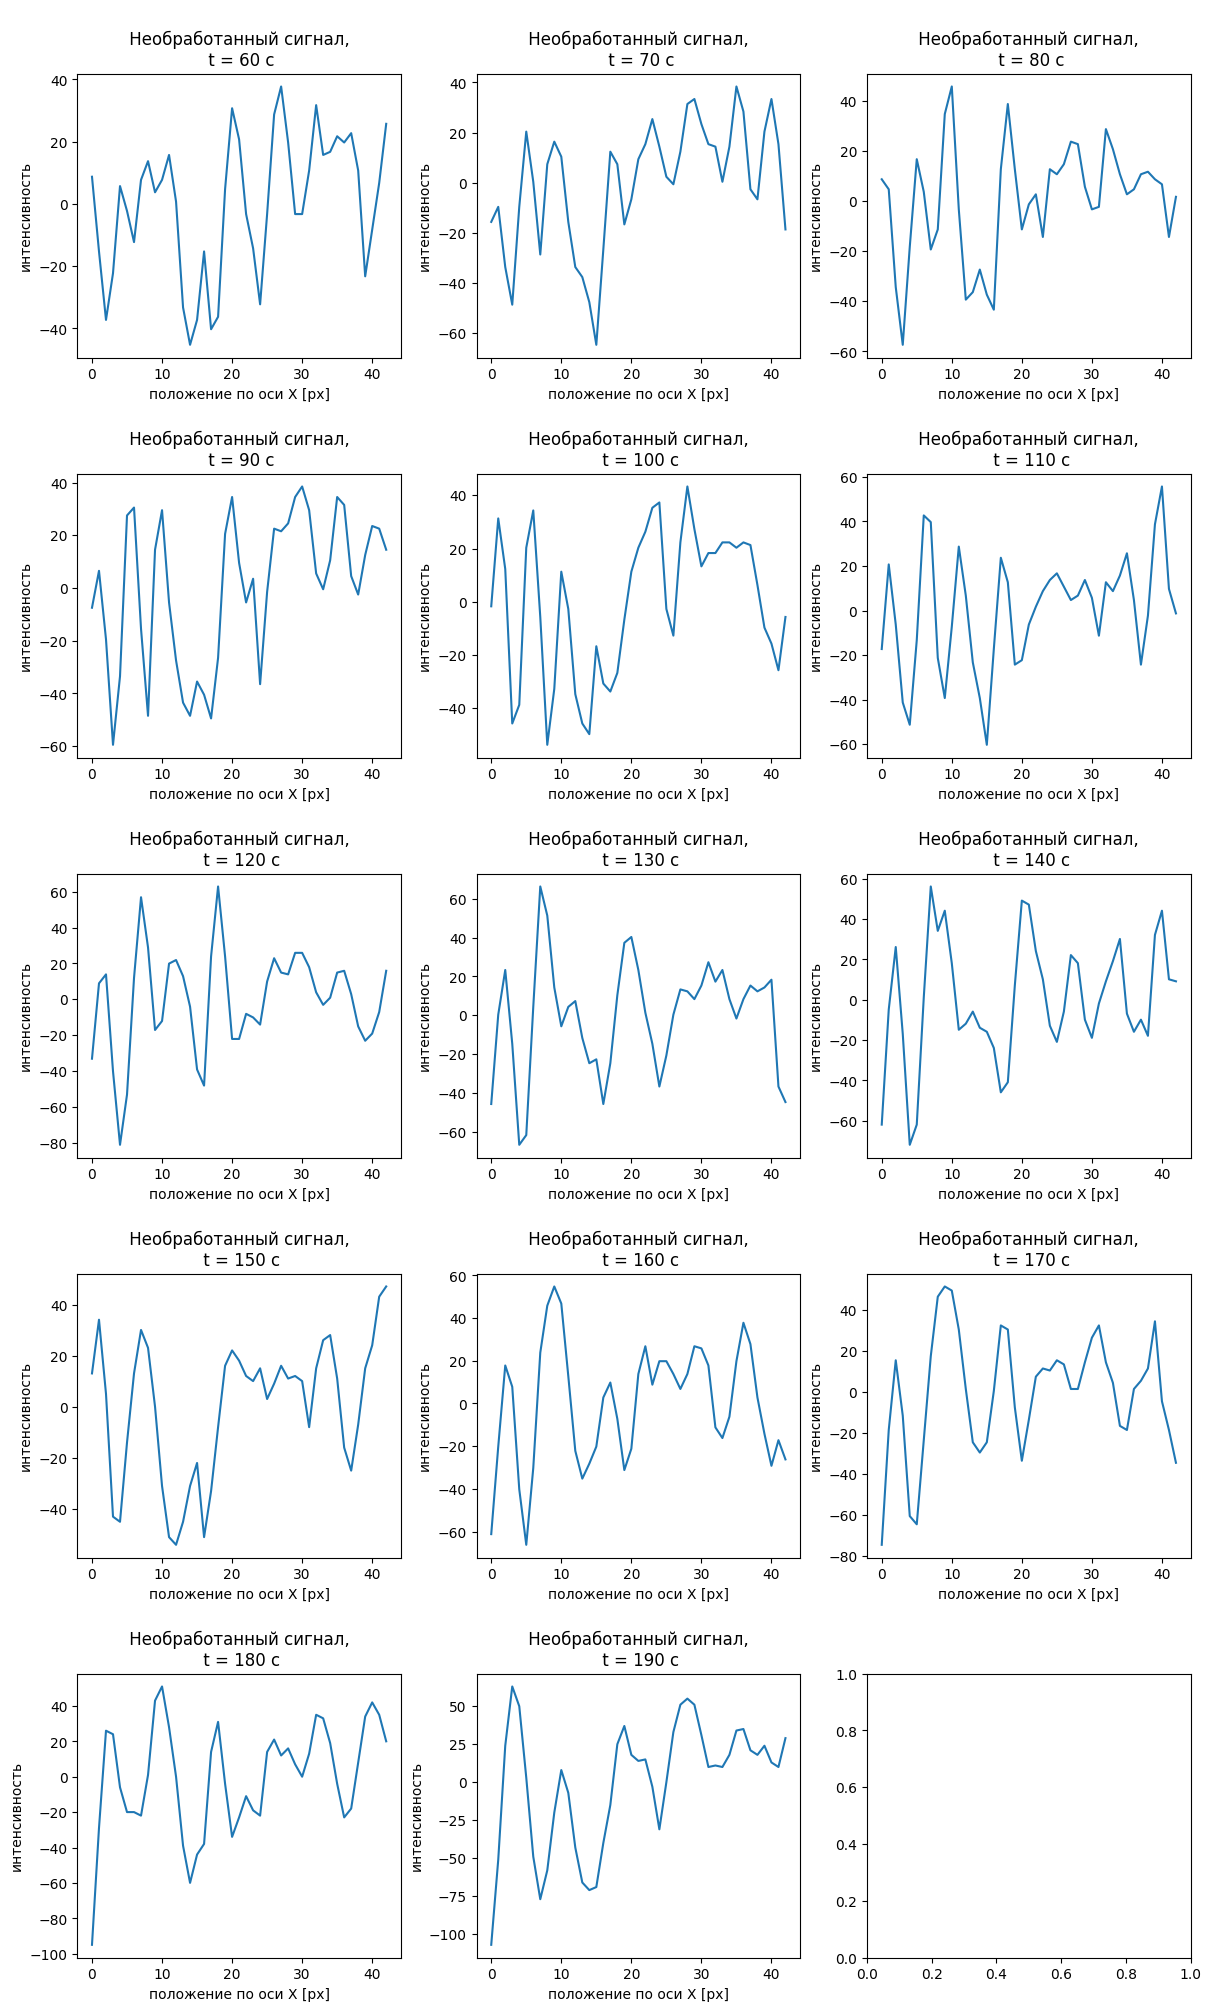

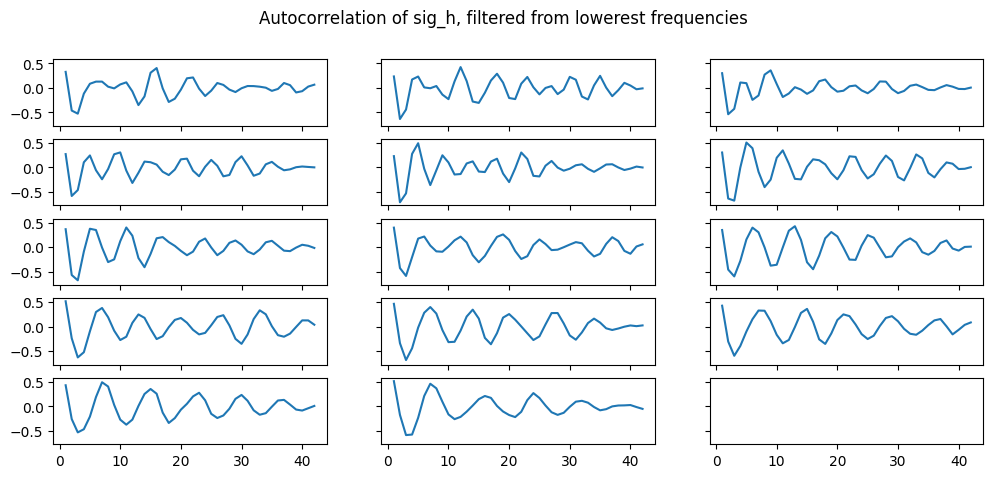

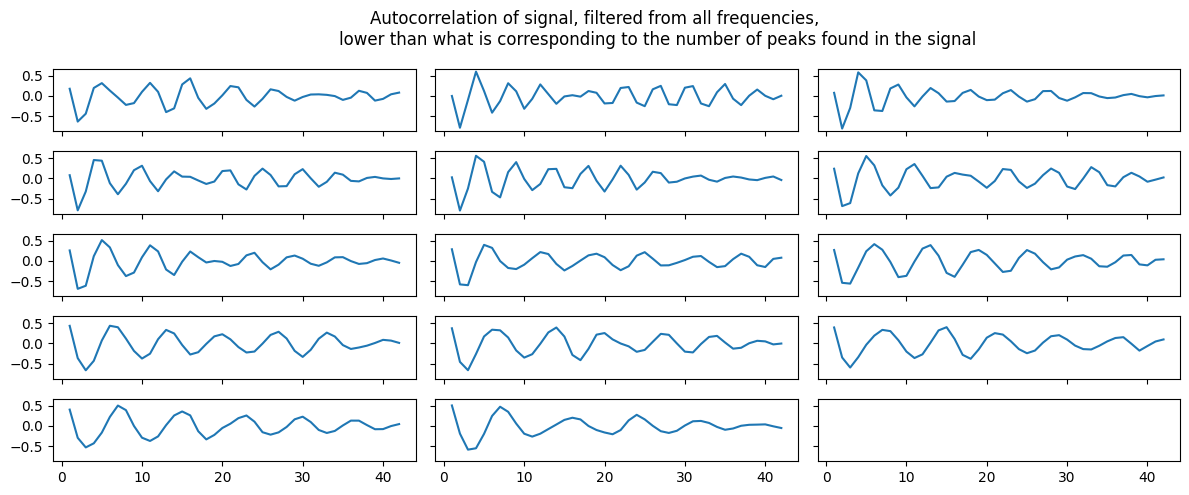

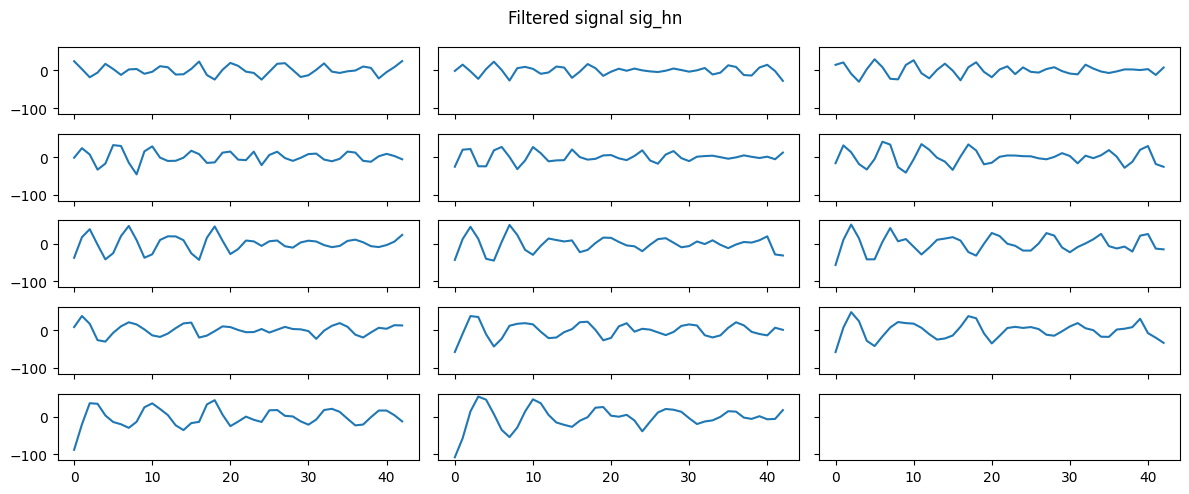

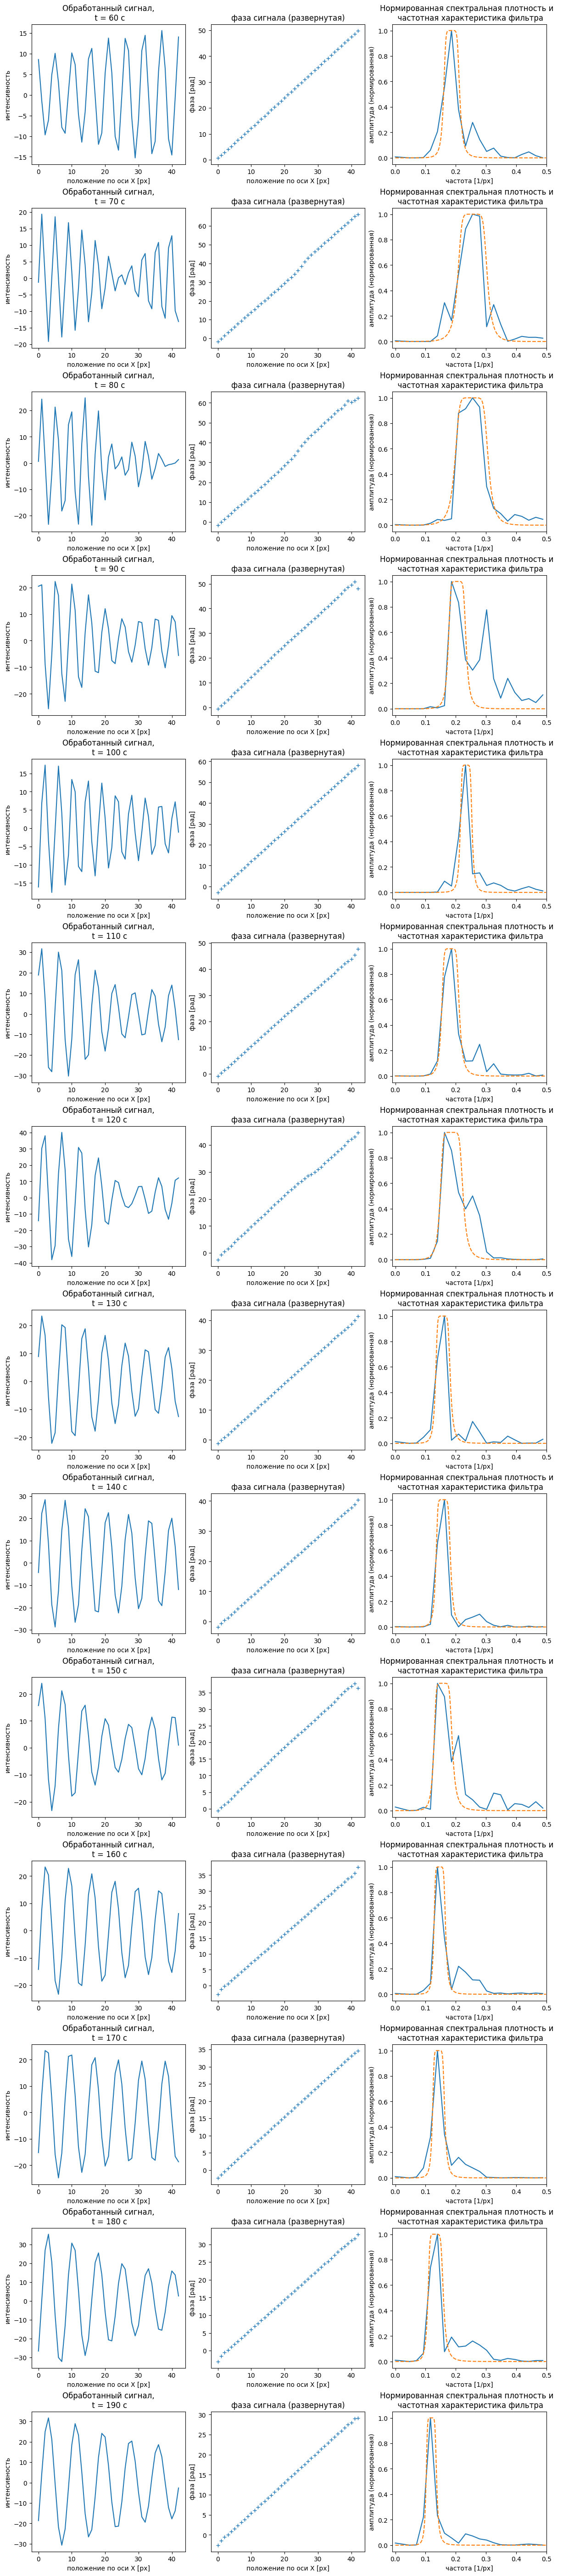

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 14) + inhomogeneous part.

In [18]:
json_14 = './json_unsertainty_estimation/09.txt'
create_raw_phase_vel_file(json_path=json_14, result_name='14ind.txt', show = True)